# Eksperimen Hyperparameter Tuning

Notebook akan menguji beberapa komponen berikut:
1. pengaruh depth dan width
2. pengaruh fungsi aktivasi
3. pengaruh learning rate

Dari setiap komponen pengujian akan dibandingkan: 
1. Hasil akhir prediksinya
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot dari setiap layer pada model

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import ffnn

In [2]:
SEED=34

In [3]:
df = pd.read_csv("../data/dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [4]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [5]:
df.shape

(10000, 12)

# Data Preprocessing

we will label encode college_tier and university_ranking_band since they have an order

In [6]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}
df["college_tier"] = df["college_tier"].map(college_tier_map)
df["college_tier"].value_counts()

college_tier
1    3993
2    3034
0    2973
Name: count, dtype: int64

In [7]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)
df["university_ranking_band"].value_counts()

university_ranking_band
0    4075
1    3975
2    1950
Name: count, dtype: int64

Target encoding for placement_status

In [8]:
target_map = {"Placed":1,"Not Placed":0}
df["placement_status"]=df["placement_status"].map(target_map)
df["placement_status"].value_counts()

placement_status
1    6153
0    3847
Name: count, dtype: int64

In [9]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [10]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='str')


/tmp/ipykernel_3782/1470084899.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object"]).columns


In [11]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='str')


### Preprocessing Pipeline

In [12]:
transformed_df = df.copy()

In [13]:
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='str')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [14]:
oh_cols = ["country","specialization","industry"]

In [15]:
onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling Experiment

In [16]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

### Control Model

The model's performance is compared with other model variation

In [17]:
control_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [18]:
control_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
control_preds = control_model.predict(X_test)
print(f1_score(y_test,control_preds))

Epoch 1/20 [..............................] 6/250

Epoch 1/20 [==============================] - train_loss: 0.522375 - val_loss: 0.531639
Epoch 2/20 [==============================] - train_loss: 0.516333 - val_loss: 0.524793
Epoch 3/20 [==============================] - train_loss: 0.517202 - val_loss: 0.525186
Epoch 4/20 [==============================] - train_loss: 0.511342 - val_loss: 0.512737
Epoch 5/20 [==============================] - train_loss: 0.513368 - val_loss: 0.518038
Epoch 6/20 [==============================] - train_loss: 0.524998 - val_loss: 0.529229
Epoch 7/20 [==============================] - train_loss: 0.515730 - val_loss: 0.521345
Epoch 8/20 [==============================] - train_loss: 0.508459 - val_loss: 0.517752
Epoch 9/20 [==============================] - train_loss: 0.510350 - val_loss: 0.517600
Epoch 10/20 [==============================] - train_loss: 0.512215 - val_loss: 0.517693
Epoch 11/20 [==============================] - train_loss: 0.508595 - val_loss: 0.512736
Epoch 12/20 [=================

### Three variation of width with the same depth like the control

Width variation: 2, 8, and 64

In [19]:
w1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 2), ffnn.Relu(), ffnn.Linear(2, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 8), ffnn.Relu(), ffnn.Linear(8, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 64), ffnn.Relu(), ffnn.Linear(64, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [20]:
w1_history = w1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w1_preds = w1_model.predict(X_test)
print(f"width = 2: {f1_score(y_test, w1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524520 - val_loss: 0.531969
Epoch 2/20 [==============================] - train_loss: 0.517696 - val_loss: 0.523235
Epoch 3/20 [==============================] - train_loss: 0.515590 - val_loss: 0.522103
Epoch 4/20 [==============================] - train_loss: 0.511575 - val_loss: 0.513117
Epoch 5/20 [==============================] - train_loss: 0.512339 - val_loss: 0.516073
Epoch 6/20 [==============================] - train_loss: 0.517222 - val_loss: 0.520090
Epoch 7/20 [==============================] - train_loss: 0.515360 - val_loss: 0.519381
Epoch 8/20 [==============================] - train_loss: 0.510091 - val_loss: 0.519338
Epoch 9/20 [==============================] - train_loss: 0.512455 - val_loss: 0.518879
Epoch 10/20 [==============================] - train_loss: 0.515240 - val_loss: 0.518838
Epoch 11/20 [==============================] - train_loss: 0.513096 - val_loss: 0.516714
Epoch 12/20 [=================

In [21]:
w2_history = w2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w2_preds = w2_model.predict(X_test)
print(f"width = 8: {f1_score(y_test, w2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.528147 - val_loss: 0.534171
Epoch 2/20 [==============================] - train_loss: 0.521722 - val_loss: 0.528427
Epoch 3/20 [==============================] - train_loss: 0.521840 - val_loss: 0.529063
Epoch 4/20 [==============================] - train_loss: 0.515039 - val_loss: 0.516361
Epoch 5/20 [==============================] - train_loss: 0.516058 - val_loss: 0.520187
Epoch 6/20 [==============================] - train_loss: 0.526455 - val_loss: 0.530657
Epoch 7/20 [==============================] - train_loss: 0.519950 - val_loss: 0.525458
Epoch 8/20 [==============================] - train_loss: 0.510778 - val_loss: 0.520171
Epoch 9/20 [==============================] - train_loss: 0.511631 - val_loss: 0.518791
Epoch 10/20 [==============================] - train_loss: 0.514971 - val_loss: 0.520140
Epoch 11/20 [==============================] - train_loss: 0.510391 - val_loss: 0.514647
Epoch 12/20 [=================

In [22]:
w3_history = w3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w3_preds = w3_model.predict(X_test)
print(f"width = 64: {f1_score(y_test, w3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.534562 - val_loss: 0.543966
Epoch 2/20 [==============================] - train_loss: 0.522616 - val_loss: 0.533807
Epoch 3/20 [==============================] - train_loss: 0.522536 - val_loss: 0.531746
Epoch 4/20 [==============================] - train_loss: 0.514412 - val_loss: 0.517442
Epoch 5/20 [==============================] - train_loss: 0.515314 - val_loss: 0.521499
Epoch 6/20 [==============================] - train_loss: 0.526081 - val_loss: 0.531633
Epoch 7/20 [==============================] - train_loss: 0.517551 - val_loss: 0.524586
Epoch 8/20 [==============================] - train_loss: 0.508879 - val_loss: 0.519081
Epoch 9/20 [==============================] - train_loss: 0.510274 - val_loss: 0.519319
Epoch 10/20 [==============================] - train_loss: 0.512275 - val_loss: 0.518476
Epoch 11/20 [==============================] - train_loss: 0.507548 - val_loss: 0.512390
Epoch 12/20 [=================

#### Perbandingan

In [23]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"width = 2: {f1_score(y_test, w1_preds)}")
print(f"width = 8: {f1_score(y_test, w2_preds)}")
print(f"width = 64: {f1_score(y_test, w3_preds)}")

control: 0.7698924731182796
width = 2: 0.7684301821335646
width = 8: 0.7677642980935875
width = 64: 0.770681525932276


##### W1 Distribution + Gradient Weight Plot

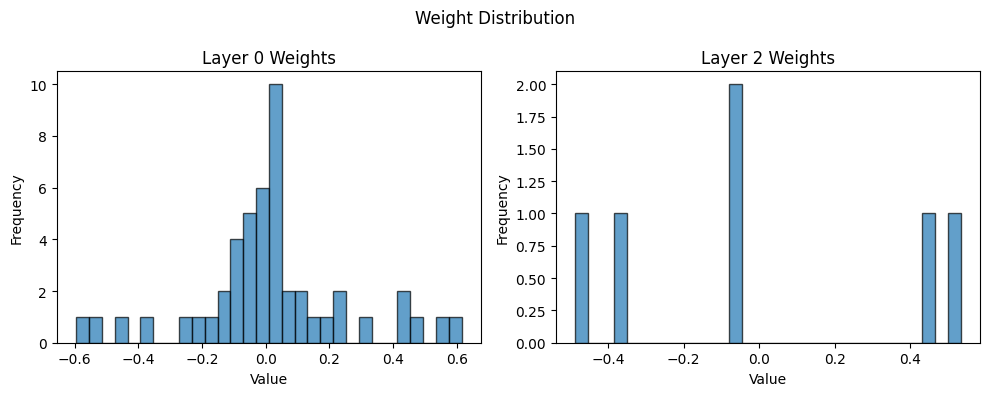

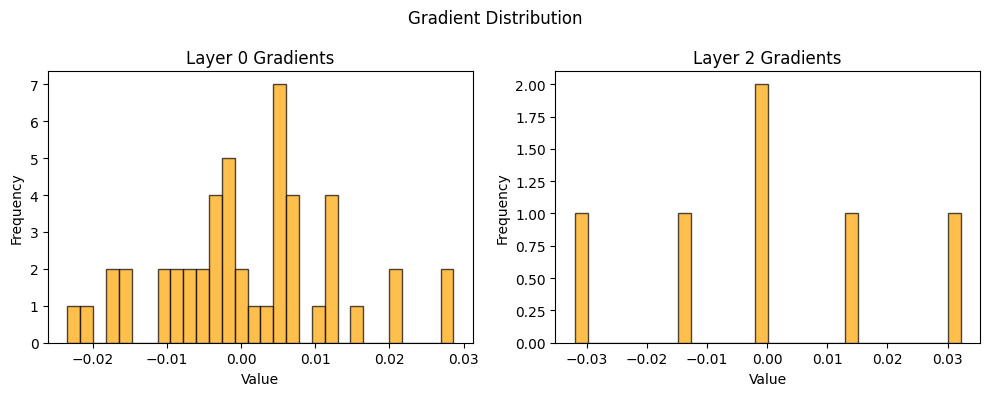

In [24]:
w1_layers = [0, 2]

w1_model.plot_weights(w1_layers)

w1_model.plot_gradients(w1_layers)

##### W2 Distribution + Gradient Weight Plot

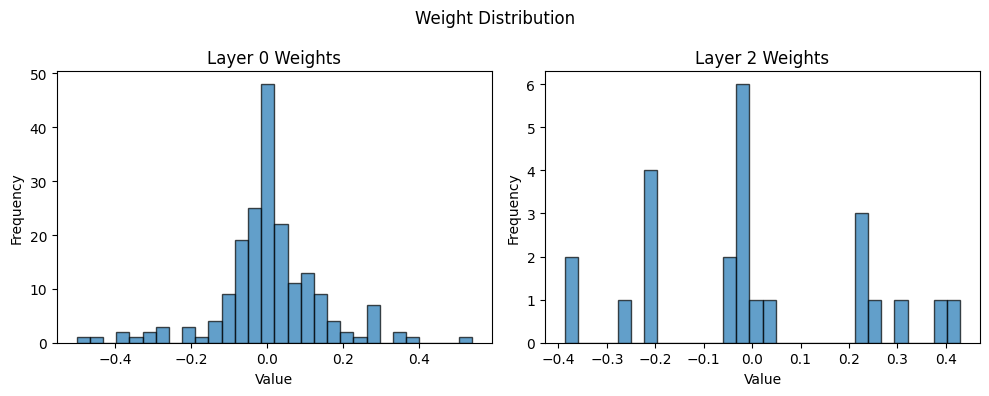

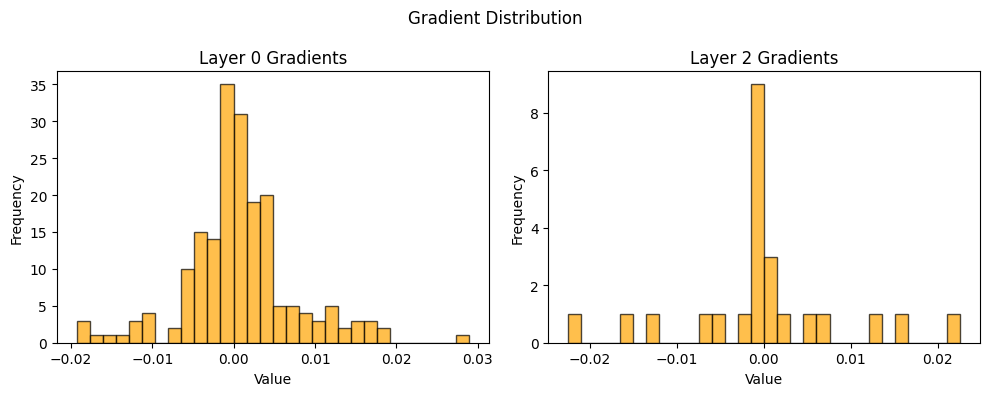

In [25]:
w2_layers = [0, 2]

w2_model.plot_weights(w2_layers)

w2_model.plot_gradients(w2_layers)

##### W3 Distribution + Gradient Weight Plot

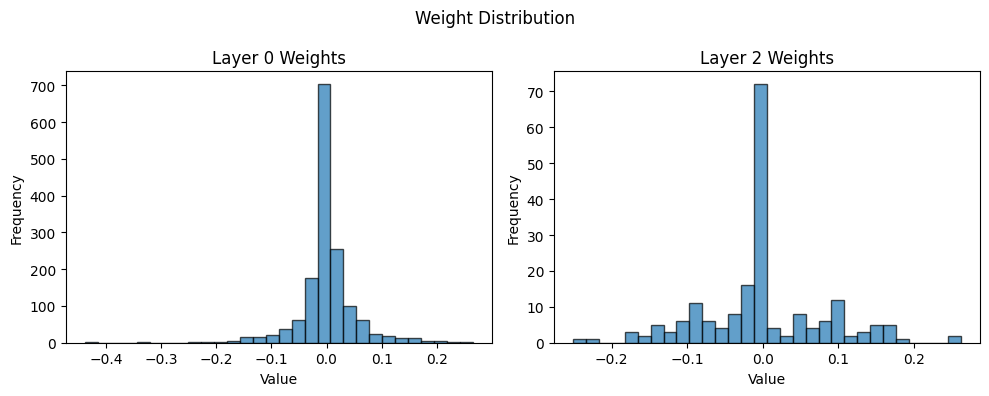

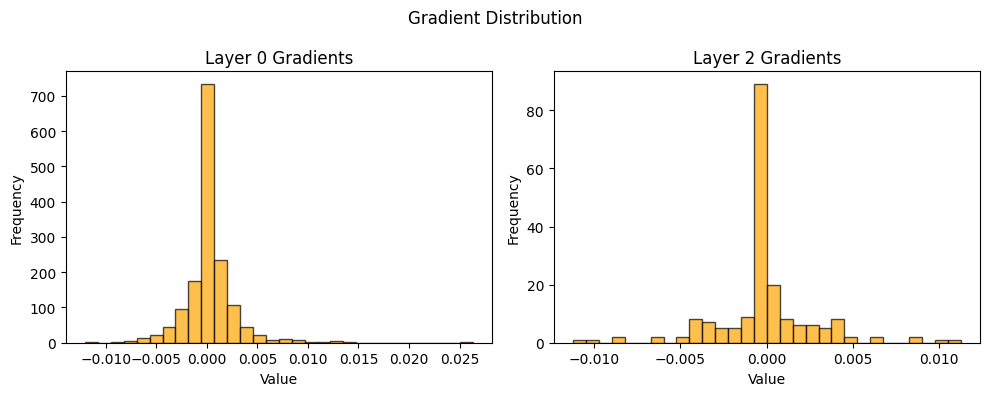

In [26]:
w3_layers = [0, 2]

w3_model.plot_weights(w3_layers)

w3_model.plot_gradients(w3_layers)

### Three variation of depth with the same width like the control

Depth variation (hidden layers): 
- 2
- 4
- 8


In [27]:
h1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

In [28]:
h1_history = h1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h1_preds = h1_model.predict(X_test)
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.527540 - val_loss: 0.536841
Epoch 2/20 [==============================] - train_loss: 0.522750 - val_loss: 0.531587
Epoch 3/20 [==============================] - train_loss: 0.529751 - val_loss: 0.535682
Epoch 4/20 [==============================] - train_loss: 0.517851 - val_loss: 0.519218
Epoch 5/20 [==============================] - train_loss: 0.522405 - val_loss: 0.528010
Epoch 6/20 [==============================] - train_loss: 0.527730 - val_loss: 0.531956
Epoch 7/20 [==============================] - train_loss: 0.524163 - val_loss: 0.529908
Epoch 8/20 [==============================] - train_loss: 0.514974 - val_loss: 0.525899
Epoch 9/20 [==============================] - train_loss: 0.515869 - val_loss: 0.523220
Epoch 10/20 [==============================] - train_loss: 0.518732 - val_loss: 0.523635
Epoch 11/20 [==============================] - train_loss: 0.518148 - val_loss: 0.521513
Epoch 12/20 [=================

In [29]:
h2_history = h2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h2_preds = h2_model.predict(X_test)
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.590807 - val_loss: 0.597570
Epoch 2/20 [==============================] - train_loss: 0.537627 - val_loss: 0.541353
Epoch 3/20 [==============================] - train_loss: 0.539014 - val_loss: 0.545855
Epoch 4/20 [==============================] - train_loss: 0.524684 - val_loss: 0.526280
Epoch 5/20 [==============================] - train_loss: 0.523865 - val_loss: 0.528310
Epoch 6/20 [==============================] - train_loss: 0.524297 - val_loss: 0.529226
Epoch 7/20 [==============================] - train_loss: 0.530927 - val_loss: 0.536866
Epoch 8/20 [==============================] - train_loss: 0.527697 - val_loss: 0.536987
Epoch 9/20 [==============================] - train_loss: 0.524450 - val_loss: 0.529991
Epoch 10/20 [==============================] - train_loss: 0.524757 - val_loss: 0.530279
Epoch 11/20 [==============================] - train_loss: 0.512987 - val_loss: 0.518663
Epoch 12/20 [=================

In [30]:
h3_history = h3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h3_preds = h3_model.predict(X_test)
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.724341 - val_loss: 0.724286
Epoch 2/20 [==============================] - train_loss: 0.702030 - val_loss: 0.701916
Epoch 3/20 [==============================] - train_loss: 0.696243 - val_loss: 0.696137
Epoch 4/20 [==============================] - train_loss: 0.691096 - val_loss: 0.690978
Epoch 5/20 [==============================] - train_loss: 0.690065 - val_loss: 0.689910
Epoch 6/20 [==============================] - train_loss: 0.691224 - val_loss: 0.691046
Epoch 7/20 [==============================] - train_loss: 0.683585 - val_loss: 0.683446
Epoch 8/20 [==============================] - train_loss: 0.681995 - val_loss: 0.681895
Epoch 9/20 [==============================] - train_loss: 0.680166 - val_loss: 0.680058
Epoch 10/20 [==============================] - train_loss: 0.681369 - val_loss: 0.681213
Epoch 11/20 [==============================] - train_loss: 0.678098 - val_loss: 0.677984
Epoch 12/20 [=================

#### Perbandingan

In [31]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

control: 0.7698924731182796
hidden layer depth = 2: 0.761443661971831
hidden layer depth = 4: 0.7630415561450045
hidden layer depth = 8: 0.7619931909625502


##### H1 Distribution + Gradient Weight Plot

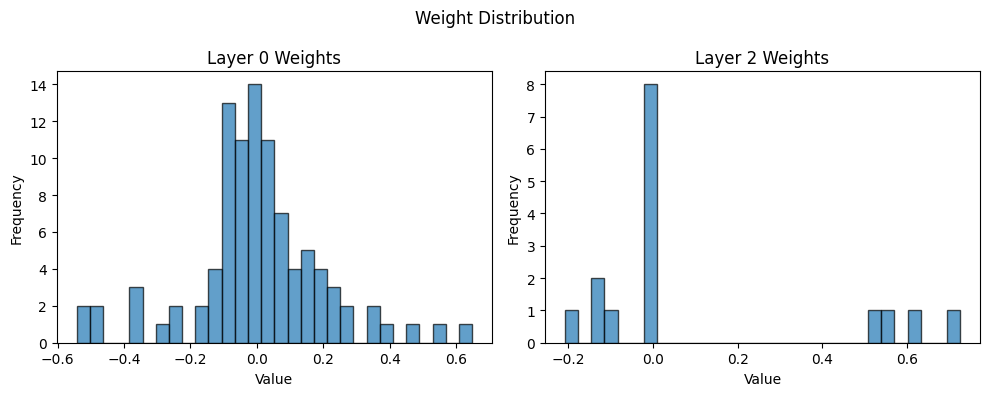

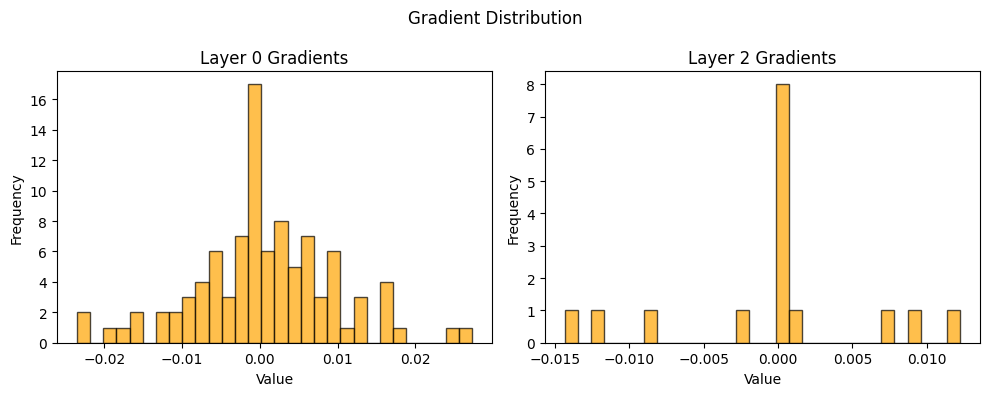

In [32]:
h1_layers = [0, 2]

h1_model.plot_weights(h1_layers)

h1_model.plot_gradients(h1_layers)

##### H2 Distribution + Gradient Weight Plot

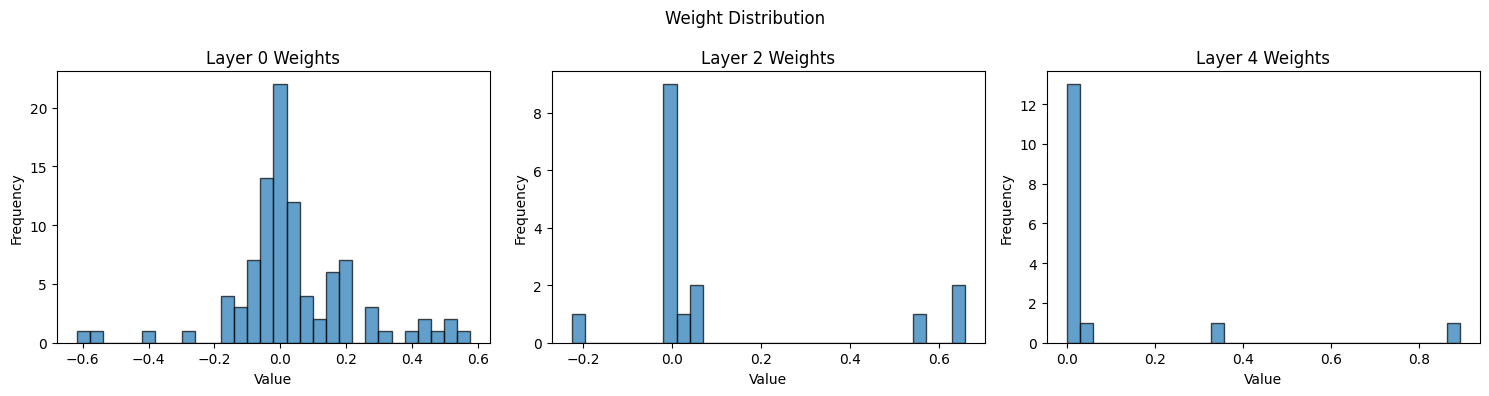

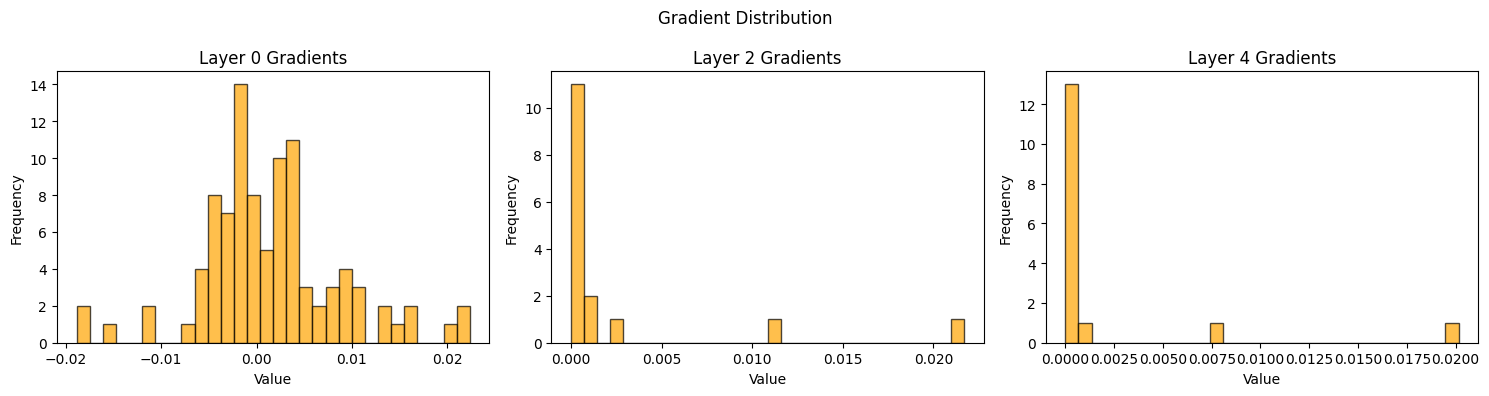

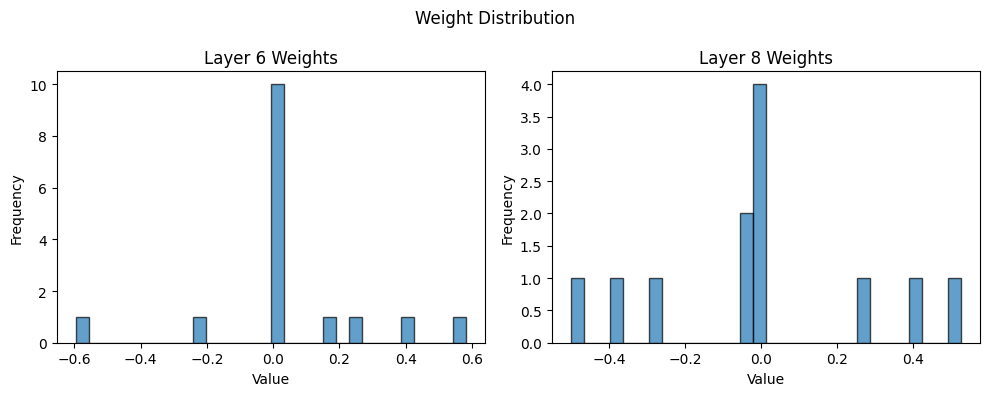

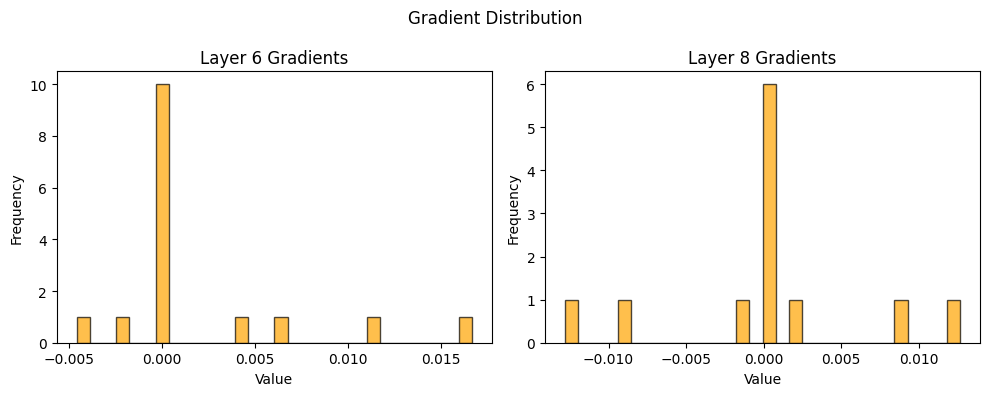

In [33]:
h2_layers = [0, 2, 4]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

h2_layers = [6, 8]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

##### H3 Distribution + Gradient Weight Plot

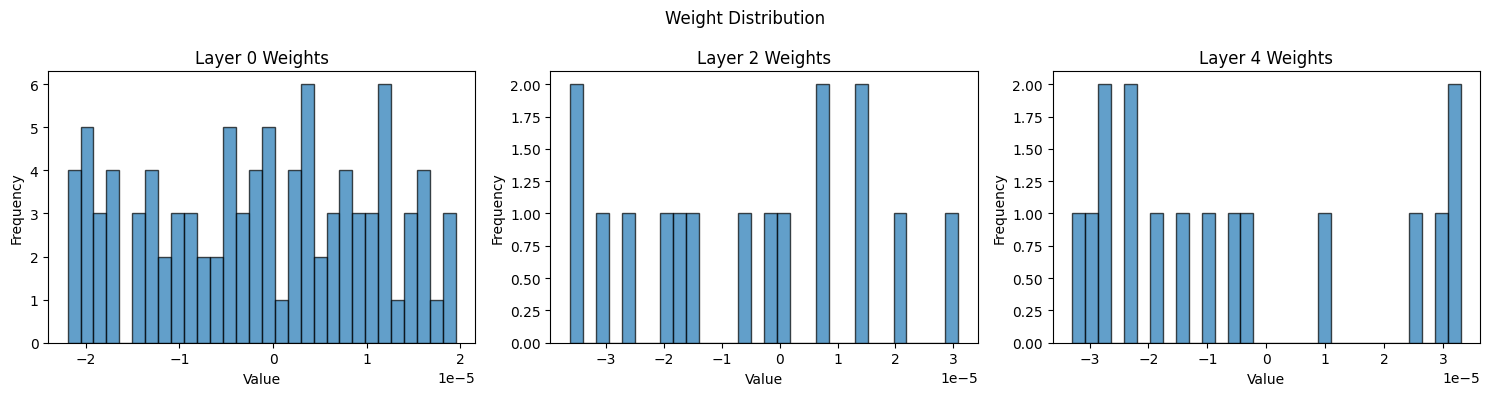

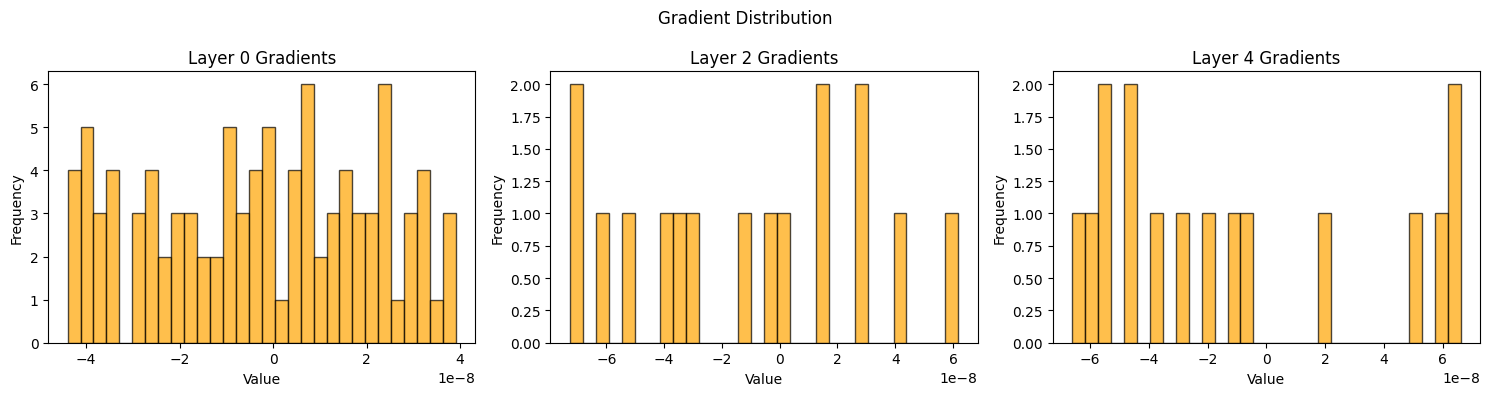

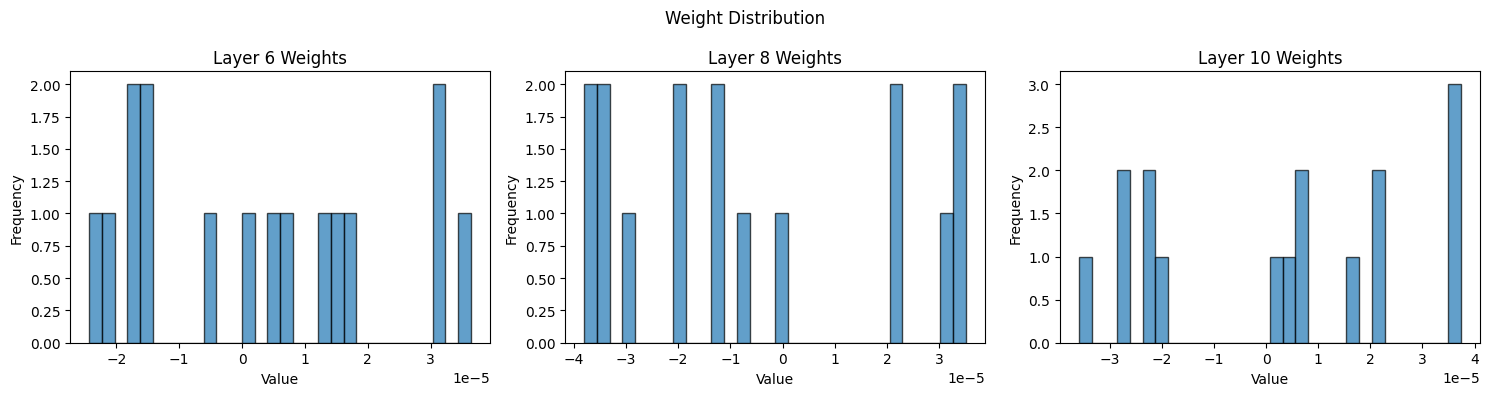

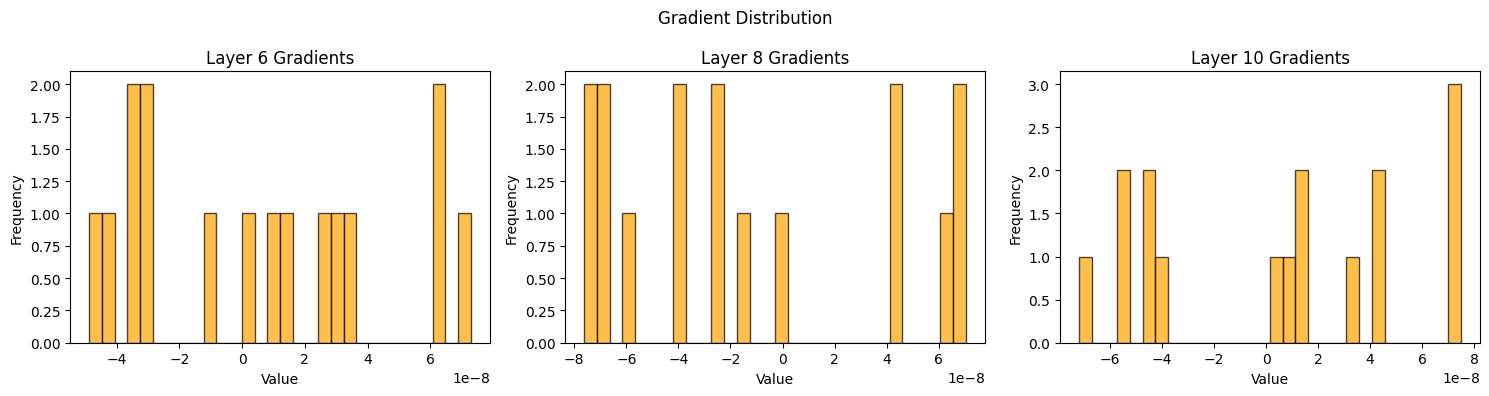

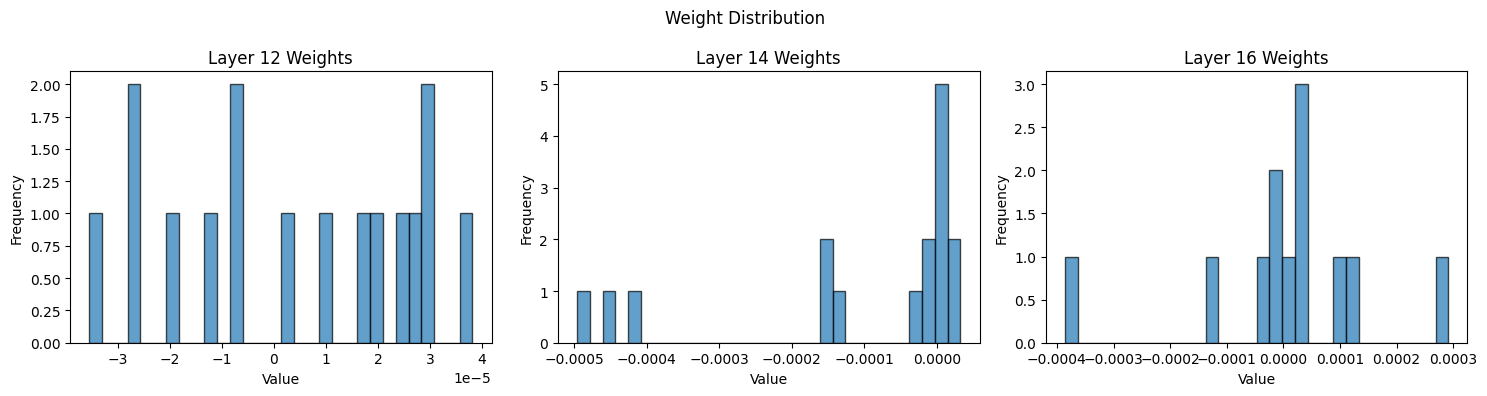

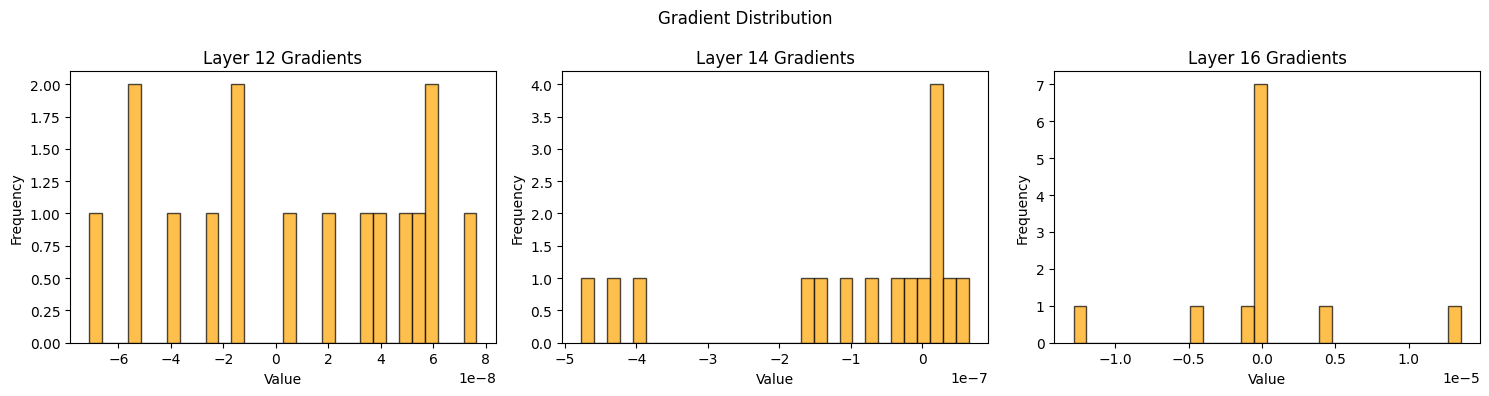

In [34]:
h3_layers = [0, 2, 4]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [6, 8, 10]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [12, 14, 16]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

### All variation of Activation Layer

FFNN is structured to have one of each input, hidden and output layer

Hidden layer variations are:

- RELU
- Leaky RELU
- ELU
- Sigmoid
- Tanh
- RMS Norm

In [35]:
relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

leaky_relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.LeakyRelu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

elu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.ELU(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

sigmoid_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Sigmoid(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

tanh_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Tanh(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

rmsnorm_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.RMSNorm(4), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)




In [36]:
relu_history = relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
relu_preds = relu_model.predict(X_test)
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.526200 - val_loss: 0.533609
Epoch 2/20 [==============================] - train_loss: 0.518894 - val_loss: 0.526729
Epoch 3/20 [==============================] - train_loss: 0.523701 - val_loss: 0.529562
Epoch 4/20 [==============================] - train_loss: 0.513719 - val_loss: 0.513724
Epoch 5/20 [==============================] - train_loss: 0.516029 - val_loss: 0.520590
Epoch 6/20 [==============================] - train_loss: 0.528769 - val_loss: 0.531661
Epoch 7/20 [==============================] - train_loss: 0.518141 - val_loss: 0.523594
Epoch 8/20 [==============================] - train_loss: 0.510309 - val_loss: 0.518847
Epoch 9/20 [==============================] - train_loss: 0.513065 - val_loss: 0.519197
Epoch 10/20 [==============================] - train_loss: 0.513051 - val_loss: 0.518485
Epoch 11/20 [==============================] - train_loss: 0.514940 - val_loss: 0.517229
Epoch 12/20 [=================

In [37]:
leaky_relu_history = leaky_relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
leaky_relu_preds = leaky_relu_model.predict(X_test)
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524334 - val_loss: 0.532861
Epoch 2/20 [==============================] - train_loss: 0.519640 - val_loss: 0.527192
Epoch 3/20 [==============================] - train_loss: 0.519698 - val_loss: 0.526175
Epoch 4/20 [==============================] - train_loss: 0.514824 - val_loss: 0.515473
Epoch 5/20 [==============================] - train_loss: 0.516128 - val_loss: 0.520908
Epoch 6/20 [==============================] - train_loss: 0.527398 - val_loss: 0.531125
Epoch 7/20 [==============================] - train_loss: 0.518640 - val_loss: 0.524881
Epoch 8/20 [==============================] - train_loss: 0.510548 - val_loss: 0.520000
Epoch 9/20 [==============================] - train_loss: 0.513250 - val_loss: 0.520544
Epoch 10/20 [==============================] - train_loss: 0.514829 - val_loss: 0.519993
Epoch 11/20 [==============================] - train_loss: 0.509997 - val_loss: 0.513516
Epoch 12/20 [=================

In [38]:
elu_history = elu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
elu_preds = elu_model.predict(X_test)
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.527171 - val_loss: 0.532512
Epoch 2/20 [==============================] - train_loss: 0.522179 - val_loss: 0.526944
Epoch 3/20 [==============================] - train_loss: 0.523538 - val_loss: 0.528771
Epoch 4/20 [==============================] - train_loss: 0.516844 - val_loss: 0.516033
Epoch 5/20 [==============================] - train_loss: 0.517463 - val_loss: 0.520346
Epoch 6/20 [==============================] - train_loss: 0.527987 - val_loss: 0.530099
Epoch 7/20 [==============================] - train_loss: 0.519694 - val_loss: 0.523045
Epoch 8/20 [==============================] - train_loss: 0.511682 - val_loss: 0.518573
Epoch 9/20 [==============================] - train_loss: 0.513980 - val_loss: 0.518759
Epoch 10/20 [==============================] - train_loss: 0.513583 - val_loss: 0.516074
Epoch 11/20 [==============================] - train_loss: 0.509074 - val_loss: 0.511257
Epoch 12/20 [=================

In [39]:
rmsnorm_history = rmsnorm_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
rmsnorm_preds = rmsnorm_model.predict(X_test)
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.531634 - val_loss: 0.538231
Epoch 2/20 [==============================] - train_loss: 0.527465 - val_loss: 0.534593
Epoch 3/20 [==============================] - train_loss: 0.527906 - val_loss: 0.534160
Epoch 4/20 [==============================] - train_loss: 0.521145 - val_loss: 0.520701
Epoch 5/20 [==============================] - train_loss: 0.521404 - val_loss: 0.525604
Epoch 6/20 [==============================] - train_loss: 0.529483 - val_loss: 0.532342
Epoch 7/20 [==============================] - train_loss: 0.522371 - val_loss: 0.526670
Epoch 8/20 [==============================] - train_loss: 0.513996 - val_loss: 0.521959
Epoch 9/20 [==============================] - train_loss: 0.516720 - val_loss: 0.522684
Epoch 10/20 [==============================] - train_loss: 0.514882 - val_loss: 0.517717
Epoch 11/20 [==============================] - train_loss: 0.510513 - val_loss: 0.512881
Epoch 12/20 [=================

In [40]:
tanh_history =tanh_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
tanh_preds = tanh_model.predict(X_test)
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.530305 - val_loss: 0.536573
Epoch 2/20 [==============================] - train_loss: 0.521530 - val_loss: 0.527331
Epoch 3/20 [==============================] - train_loss: 0.519638 - val_loss: 0.525474
Epoch 4/20 [==============================] - train_loss: 0.513880 - val_loss: 0.513111
Epoch 5/20 [==============================] - train_loss: 0.514049 - val_loss: 0.517617
Epoch 6/20 [==============================] - train_loss: 0.522825 - val_loss: 0.525137
Epoch 7/20 [==============================] - train_loss: 0.517186 - val_loss: 0.520954
Epoch 8/20 [==============================] - train_loss: 0.509492 - val_loss: 0.516966
Epoch 9/20 [==============================] - train_loss: 0.512641 - val_loss: 0.517739
Epoch 10/20 [==============================] - train_loss: 0.513108 - val_loss: 0.515649
Epoch 11/20 [==============================] - train_loss: 0.508494 - val_loss: 0.510696
Epoch 12/20 [=================

In [41]:
sigmoid_history = sigmoid_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
sigmoid_preds = sigmoid_model.predict(X_test)
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.532034 - val_loss: 0.535251
Epoch 2/20 [==============================] - train_loss: 0.528337 - val_loss: 0.532354
Epoch 3/20 [==============================] - train_loss: 0.526096 - val_loss: 0.530398
Epoch 4/20 [==============================] - train_loss: 0.521039 - val_loss: 0.521958
Epoch 5/20 [==============================] - train_loss: 0.522634 - val_loss: 0.525203
Epoch 6/20 [==============================] - train_loss: 0.529017 - val_loss: 0.530675
Epoch 7/20 [==============================] - train_loss: 0.521728 - val_loss: 0.524538
Epoch 8/20 [==============================] - train_loss: 0.514950 - val_loss: 0.519330
Epoch 9/20 [==============================] - train_loss: 0.516231 - val_loss: 0.519296
Epoch 10/20 [==============================] - train_loss: 0.517096 - val_loss: 0.518816
Epoch 11/20 [==============================] - train_loss: 0.515770 - val_loss: 0.518223
Epoch 12/20 [=================

#### Perbandingan

In [42]:

print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")


control: 0.7698924731182796
hidden layer activation = RELU: 0.7705479452054794
hidden layer activation = Leaky RELU: 0.7662168045276447
hidden layer activation = ELU: 0.7740281930798804
hidden layer activation = RMS Norm: 0.7726495726495727
hidden layer activation = Tanh: 0.7701595515308323
hidden layer activation = Sigmoid: 0.7694289394589953


In [43]:
hidden_layers = [0, 2]

##### RELU Distribution + Gradient Weight Plot

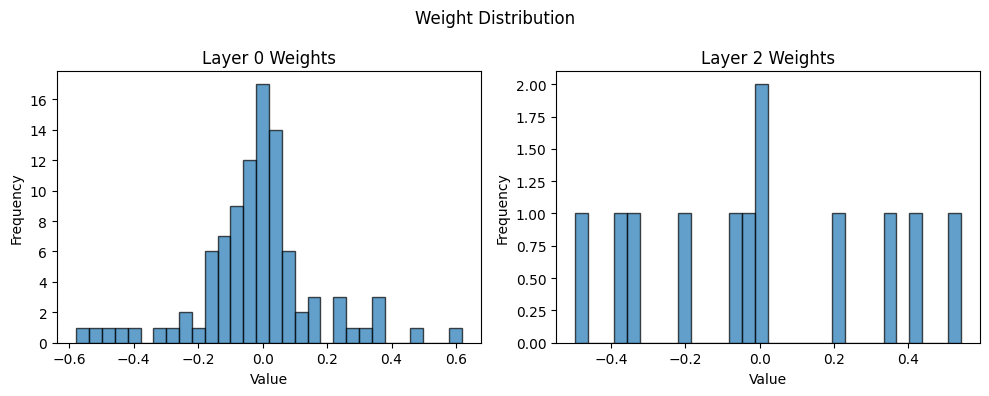

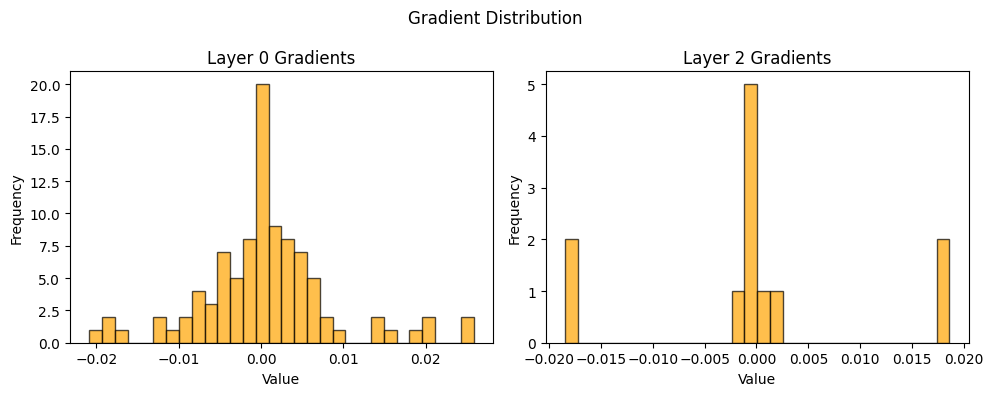

In [44]:
relu_model.plot_weights(hidden_layers)

relu_model.plot_gradients(hidden_layers)

##### Leaky RELU Distribution + Gradient Weight Plot

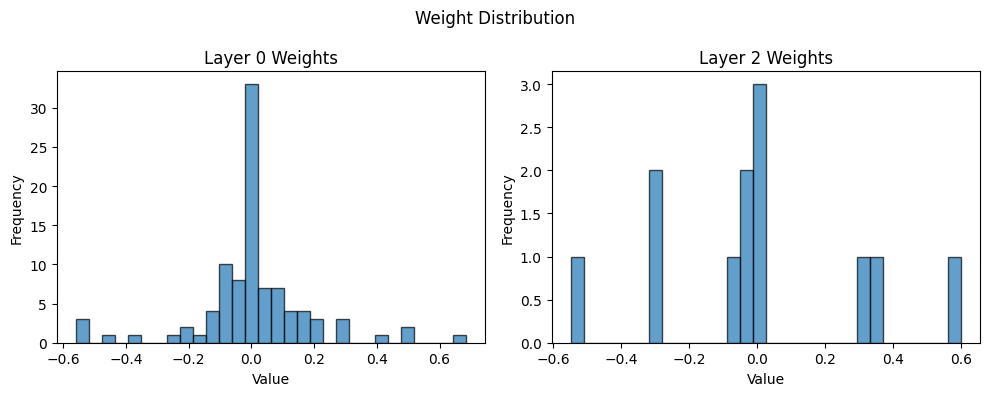

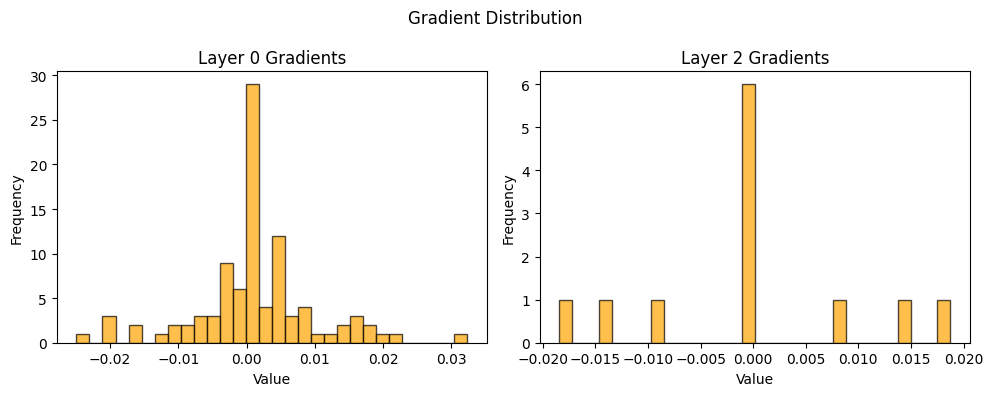

In [45]:
leaky_relu_model.plot_weights(hidden_layers)

leaky_relu_model.plot_gradients(hidden_layers)

##### ELU Distribution + Gradient Weight Plot

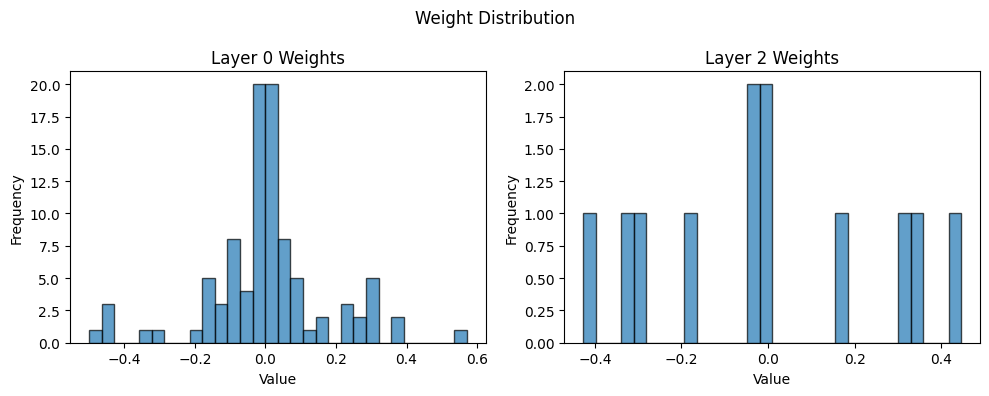

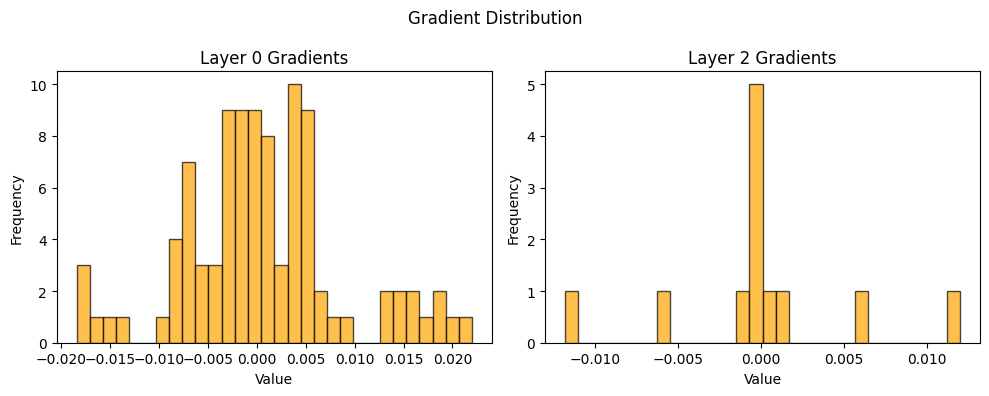

In [46]:
elu_model.plot_weights(hidden_layers)

elu_model.plot_gradients(hidden_layers)

##### RMS Norm Distribution + Gradient Weight Plot

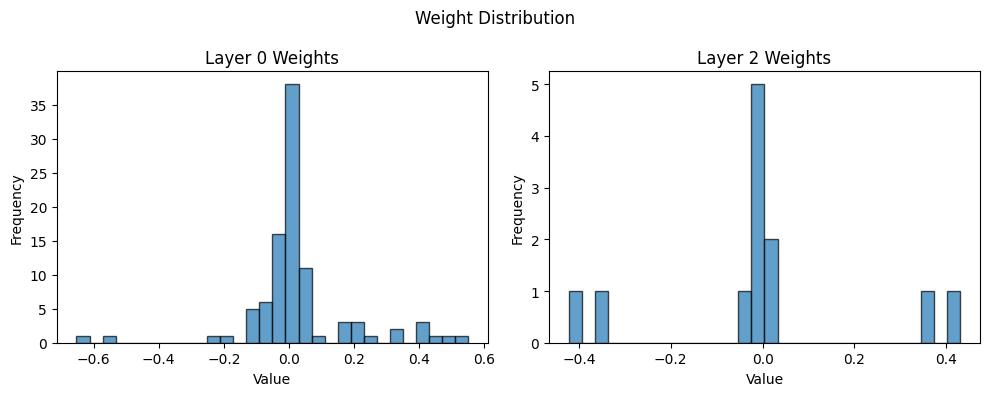

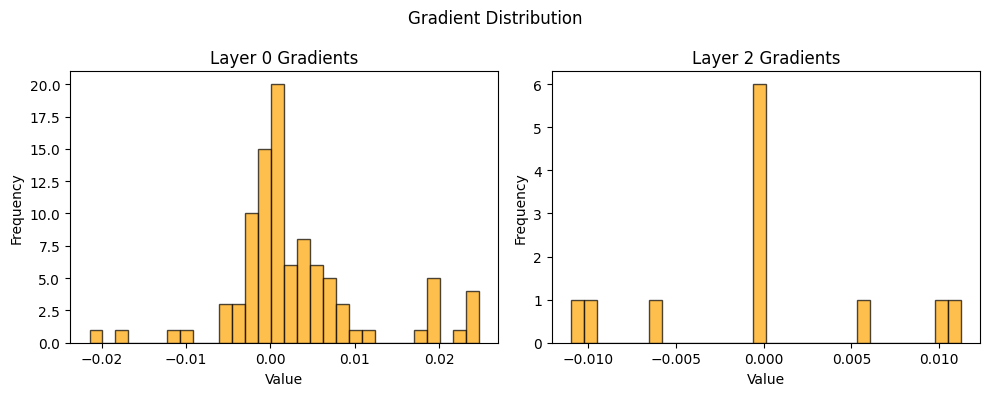

In [47]:
rmsnorm_model.plot_weights(hidden_layers)

rmsnorm_model.plot_gradients(hidden_layers)

##### Tanh Distribution + Gradient Weight Plot

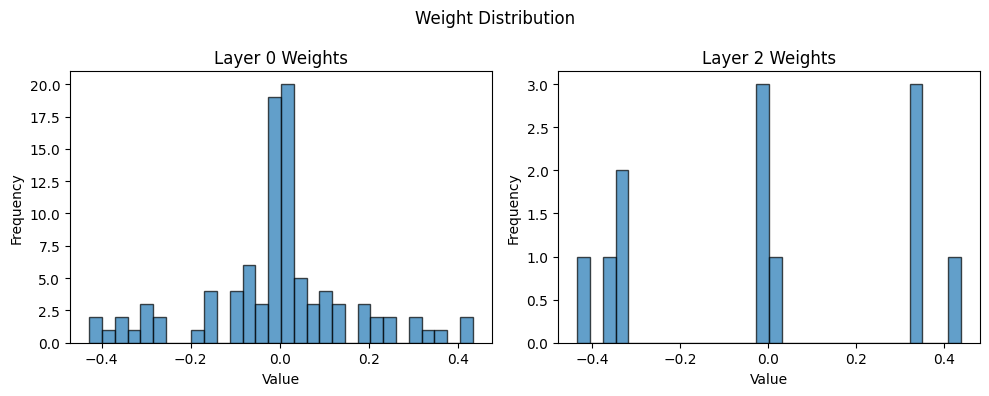

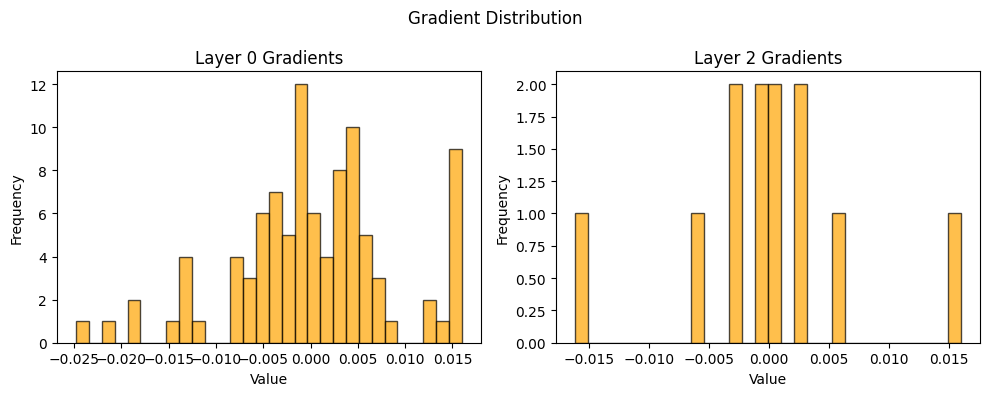

In [48]:
tanh_model.plot_weights(hidden_layers)

tanh_model.plot_gradients(hidden_layers)

##### Sigmoid Distribution + Gradient Weight Plot

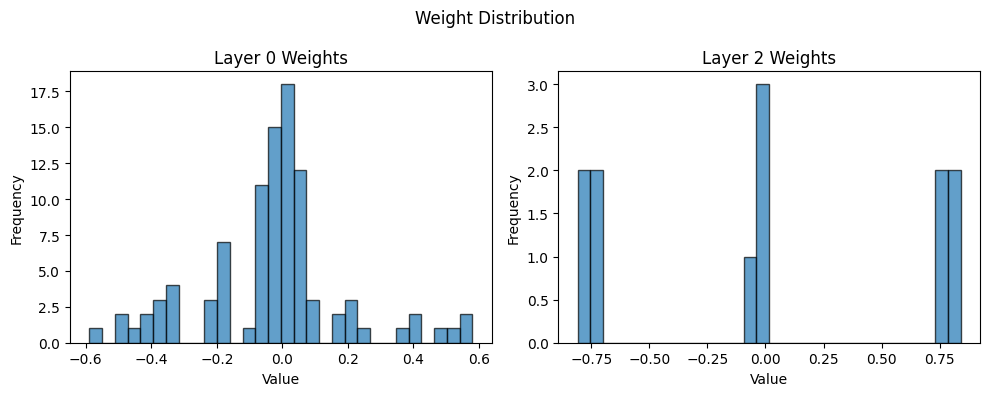

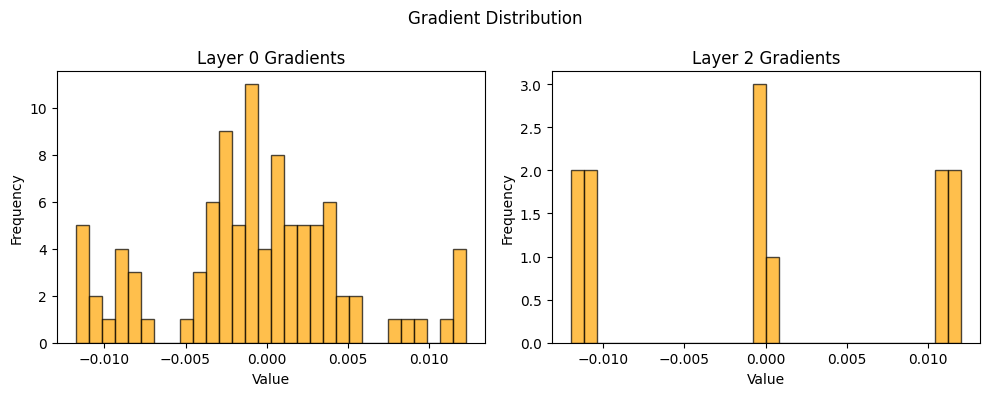

In [49]:
sigmoid_model.plot_weights(hidden_layers)

sigmoid_model.plot_gradients(hidden_layers)

### Three variation of Learning Rate

Using the same control model, we will modify the learning rate when fitting train data

Variation of learning rates:

- 0.01
- 0.1
- 1.1

In [50]:
lr1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [51]:
lr1_history = lr1_model.fit(X_train, y_train, epochs=20, lr=0.01, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr1_preds = lr1_model.predict(X_test)
print(f"Learning Rate = 0.1: {f1_score(y_test,lr1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.989445 - val_loss: 0.983349
Epoch 2/20 [==============================] - train_loss: 0.875613 - val_loss: 0.870019
Epoch 3/20 [==============================] - train_loss: 0.819429 - val_loss: 0.814469
Epoch 4/20 [==============================] - train_loss: 0.782297 - val_loss: 0.778055
Epoch 5/20 [==============================] - train_loss: 0.753837 - val_loss: 0.750243
Epoch 6/20 [==============================] - train_loss: 0.730269 - val_loss: 0.727377
Epoch 7/20 [==============================] - train_loss: 0.709840 - val_loss: 0.707612
Epoch 8/20 [==============================] - train_loss: 0.691678 - val_loss: 0.689933
Epoch 9/20 [==============================] - train_loss: 0.675316 - val_loss: 0.673917
Epoch 10/20 [==============================] - train_loss: 0.660470 - val_loss: 0.659607
Epoch 11/20 [==============================] - train_loss: 0.646939 - val_loss: 0.646576
Epoch 12/20 [=================

In [52]:
lr2_history = lr2_model.fit(X_train, y_train, epochs=20, lr=0.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr2_preds = lr2_model.predict(X_test)
print(f"Learning Rate = 10: {f1_score(y_test,lr2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.640326 - val_loss: 0.642243
Epoch 2/20 [==============================] - train_loss: 0.580613 - val_loss: 0.582523
Epoch 3/20 [==============================] - train_loss: 0.554684 - val_loss: 0.557105
Epoch 4/20 [==============================] - train_loss: 0.539790 - val_loss: 0.542136
Epoch 5/20 [==============================] - train_loss: 0.530904 - val_loss: 0.533553
Epoch 6/20 [==============================] - train_loss: 0.525992 - val_loss: 0.529013
Epoch 7/20 [==============================] - train_loss: 0.521293 - val_loss: 0.525787
Epoch 8/20 [==============================] - train_loss: 0.517993 - val_loss: 0.523111
Epoch 9/20 [==============================] - train_loss: 0.516655 - val_loss: 0.520981
Epoch 10/20 [==============================] - train_loss: 0.515147 - val_loss: 0.519608
Epoch 11/20 [==============================] - train_loss: 0.513584 - val_loss: 0.518505
Epoch 12/20 [=================

In [53]:
lr3_history = lr3_model.fit(X_train, y_train, epochs=20, lr=1.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr3_preds = lr3_model.predict(X_test)
print(f"Learning Rate = 40: {f1_score(y_test,lr3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.523101 - val_loss: 0.532049
Epoch 2/20 [==============================] - train_loss: 0.518267 - val_loss: 0.526863
Epoch 3/20 [==============================] - train_loss: 0.518829 - val_loss: 0.526622
Epoch 4/20 [==============================] - train_loss: 0.512990 - val_loss: 0.513847
Epoch 5/20 [==============================] - train_loss: 0.514745 - val_loss: 0.519160
Epoch 6/20 [==============================] - train_loss: 0.527584 - val_loss: 0.531263
Epoch 7/20 [==============================] - train_loss: 0.517014 - val_loss: 0.523178
Epoch 8/20 [==============================] - train_loss: 0.509652 - val_loss: 0.519469
Epoch 9/20 [==============================] - train_loss: 0.512365 - val_loss: 0.520167
Epoch 10/20 [==============================] - train_loss: 0.514099 - val_loss: 0.518992
Epoch 11/20 [==============================] - train_loss: 0.509938 - val_loss: 0.513703
Epoch 12/20 [=================

#### Perbandingan

In [54]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"Learning Rate = 0.01: {f1_score(y_test,lr1_preds)}")
print(f"Learning Rate = 0.1: {f1_score(y_test,lr2_preds)}")
print(f"Learning Rate = 1.1: {f1_score(y_test,lr3_preds)}")

control: 0.7698924731182796
Learning Rate = 0.01: 0.8025127601099332
Learning Rate = 0.1: 0.7982207844723008
Learning Rate = 1.1: 0.7694300518134715


In [55]:
lr_layers = [0, 2]

##### lr1 Distribution + Gradient Weight Plot

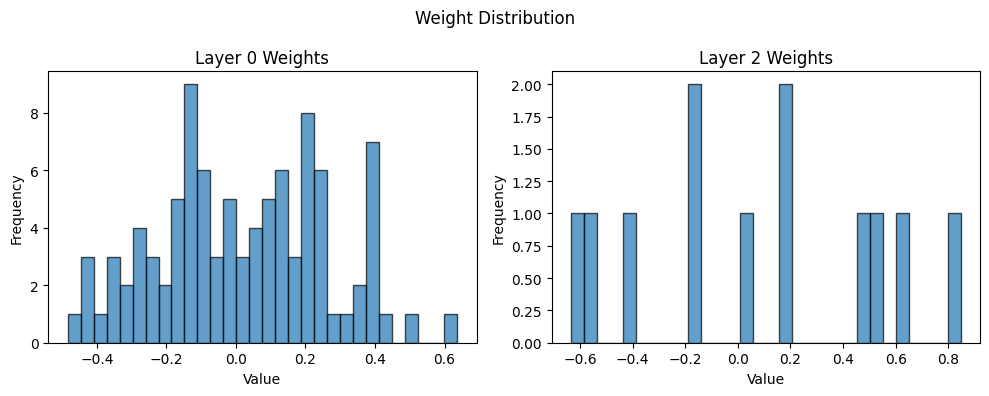

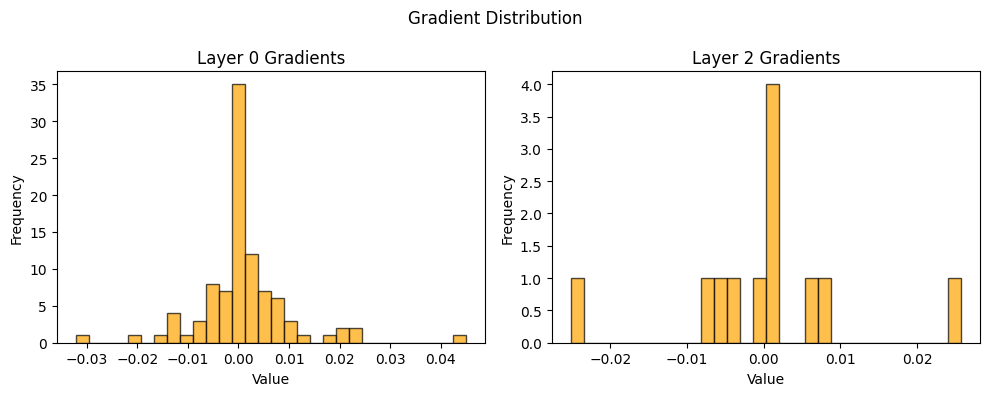

In [56]:
lr1_model.plot_weights(lr_layers)

lr1_model.plot_gradients(lr_layers)

##### lr2 Distribution + Gradient Weight Plot

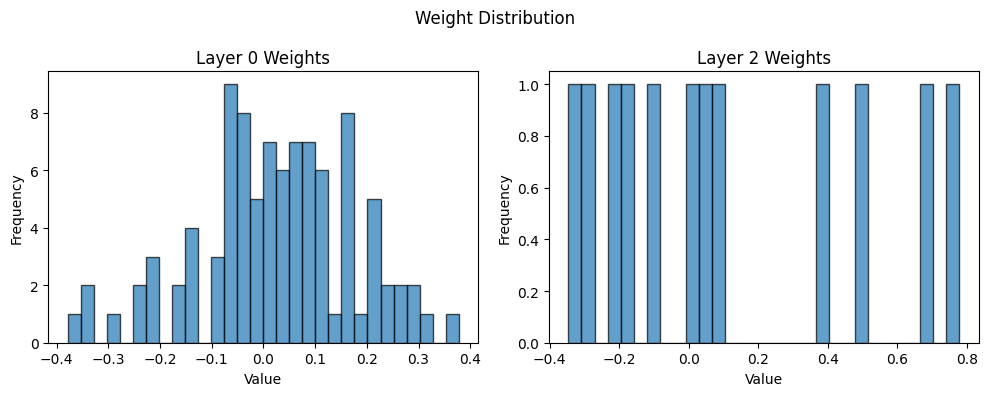

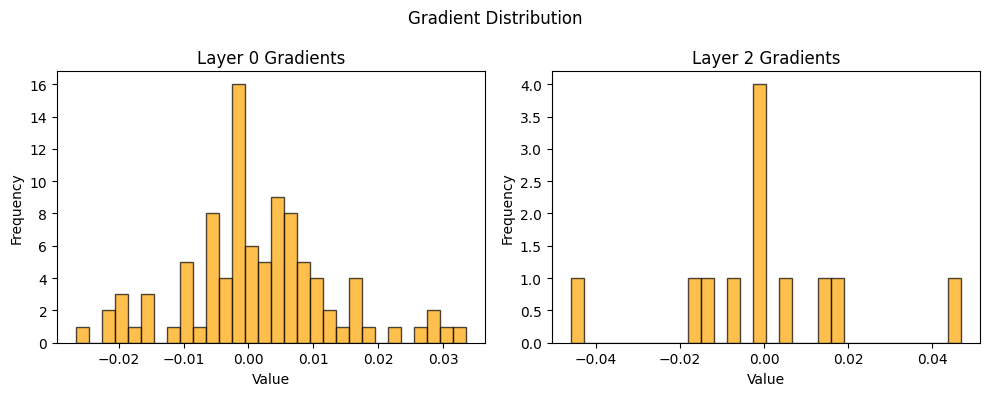

In [57]:
lr2_model.plot_weights(lr_layers)

lr2_model.plot_gradients(lr_layers)

##### lr3 Distribution + Gradient Weight Plot

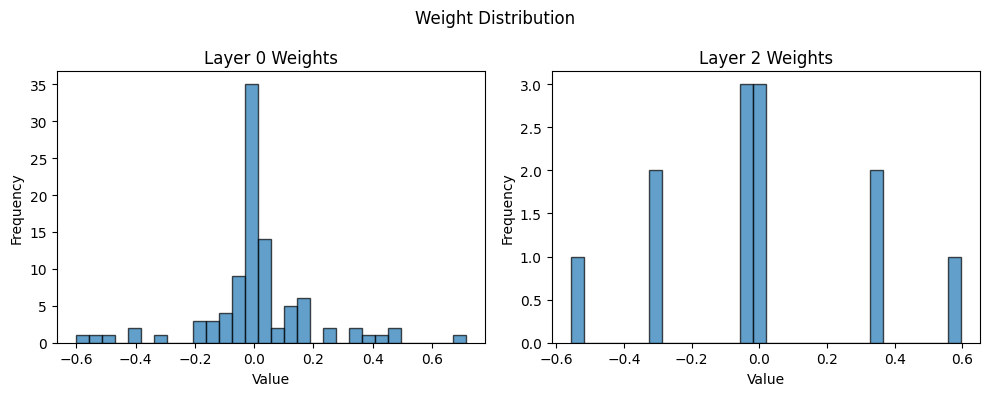

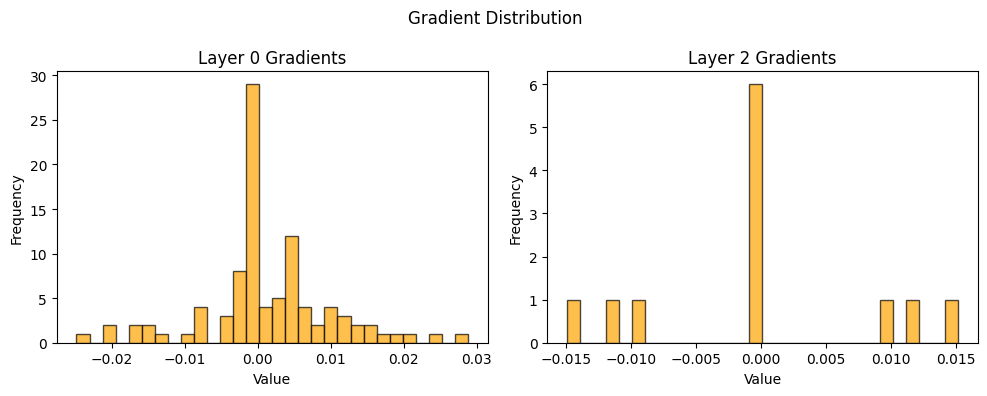

In [58]:
lr3_model.plot_weights(lr_layers)

lr3_model.plot_gradients(lr_layers)

### Training & Validation Loss Graphs

Display Training Loss & Validation Loss on each graph

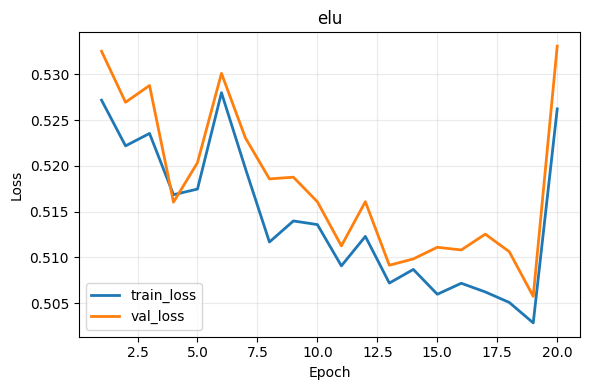

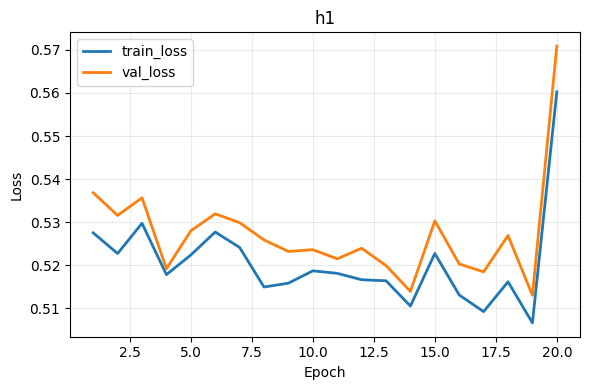

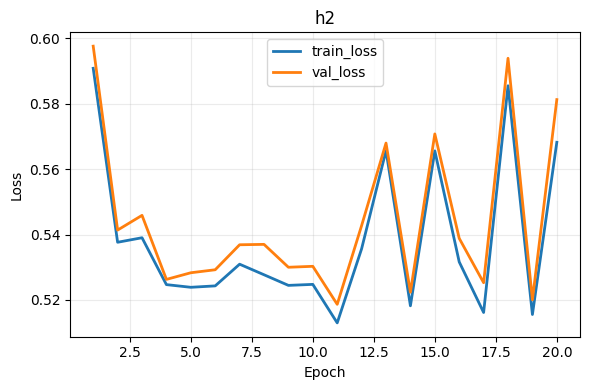

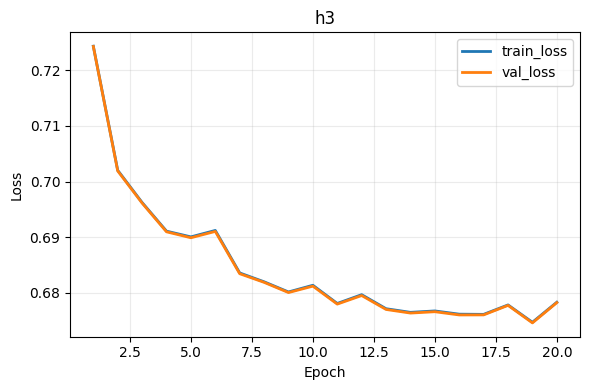

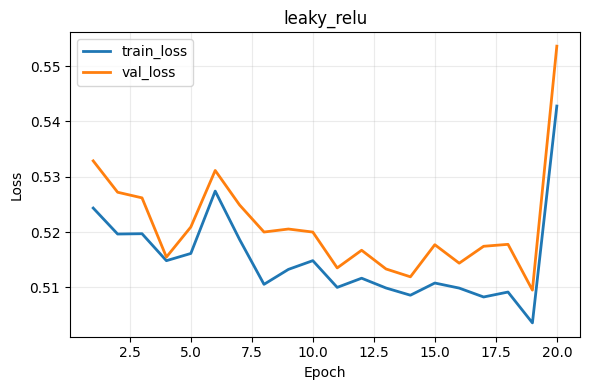

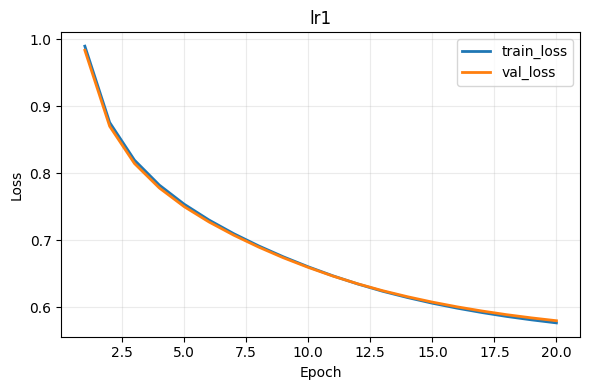

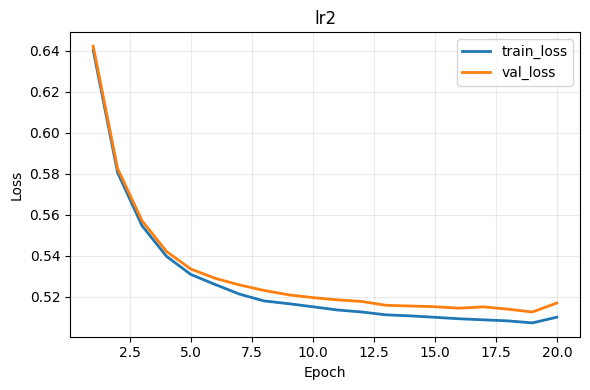

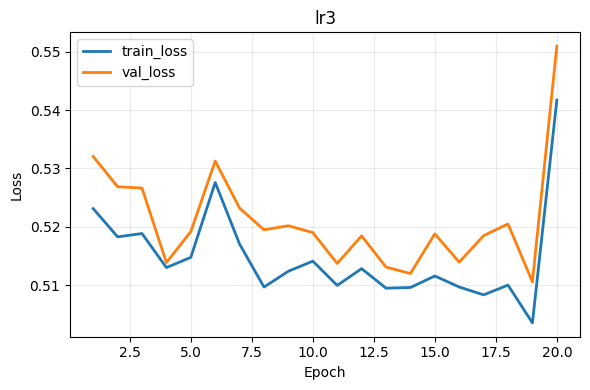

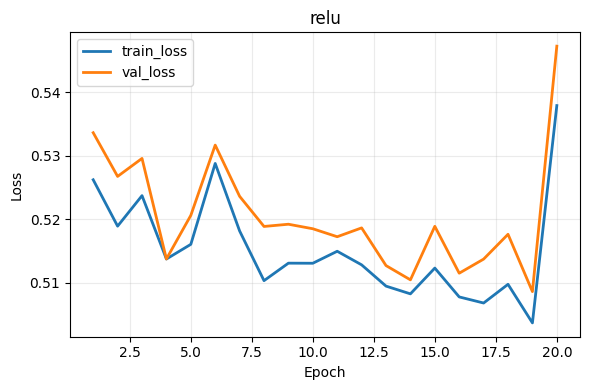

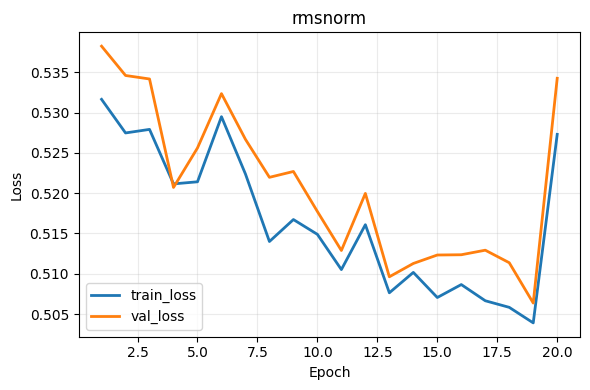

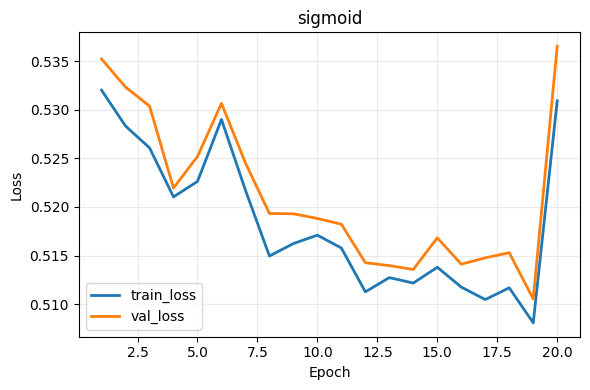

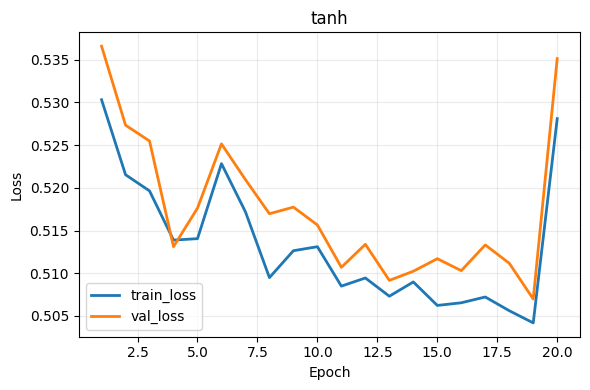

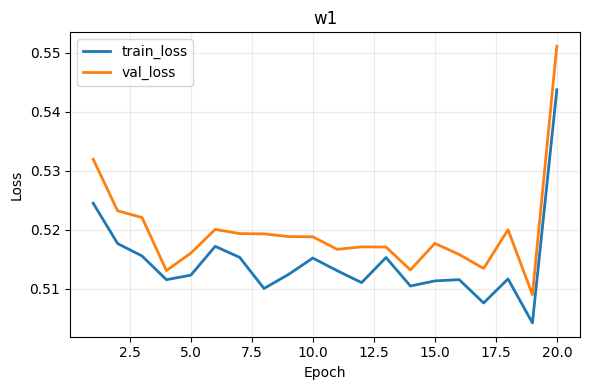

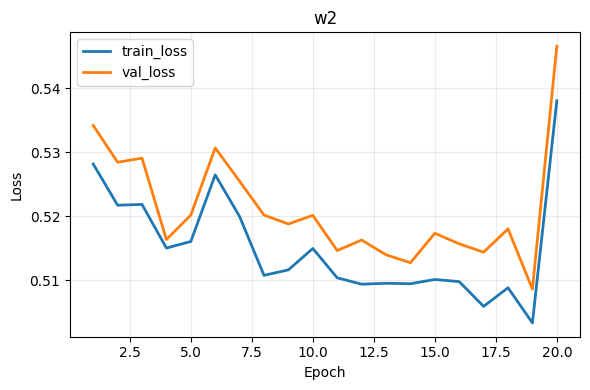

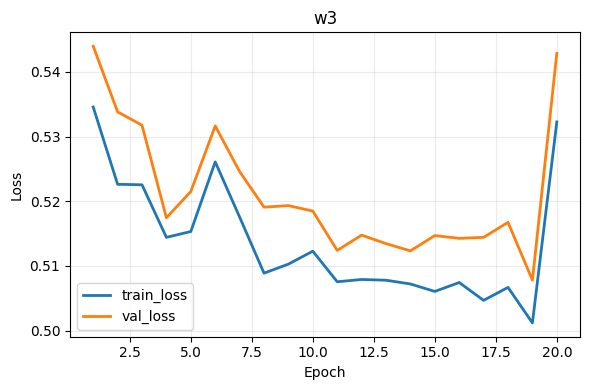

In [59]:
history_items = sorted(
    (name, value)
    for name, value in globals().items()
    if name.endswith("_history") and isinstance(value, dict)
)

if not history_items:
    raise ValueError("No *_history variables found. Run the training cells first.")

for name, history in history_items:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    train_loss = history.get("train_loss", [])
    val_loss = history.get("val_loss", [])

    if train_loss:
        train_epochs = range(1, len(train_loss) + 1)
        ax.plot(train_epochs, train_loss, label="train_loss", linewidth=2)

    if val_loss:
        val_epochs = range(1, len(val_loss) + 1)
        ax.plot(val_epochs, val_loss, label="val_loss", linewidth=2)
    else:
        ax.text(
            0.5,
            0.1,
            "val_loss unavailable",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=9,
            color="gray",
        )

    ax.set_title(name.replace("_history", ""))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()